# 04 — Behaviour × trajectory

Both arms, \(n = 54\). Trajectory metrics from `genre_source == utterance`.

Two grains: **D** = person-level planned \(D_i\), same contrast on both sides, Spearman; **RM** = condition-state repeated-measures correlation with the person centred out (Bakdash & Marusich; df = N − k − 1). Association, not mediation. Holm is within `combo × grain × contrast`; BH is across all 2,560 combo tests. **Result: zero Holm-family and zero BH-global hits in this family**; what follows shows the raw landscape so the null is visible, not asserted.

Rebuild: `python analysis/walter/combos/run_combos.py`.

In [1]:
from pathlib import Path
import json, sys, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

HERE = Path.cwd().resolve()
while not (HERE / "analysis" / "walter" / "statkit.py").exists():
    HERE = HERE.parent
WALTER = HERE / "analysis" / "walter"
for p in (WALTER, WALTER / "behavioural" / "stats", WALTER / "combos"):
    sys.path.insert(0, str(p))
import statkit as sk
import viz
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 42)
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
GOLD = WALTER / "behavioural" / "outputs" / "gold"
import run_combos as rcb
OUT = rcb.OUT / "beh_traj"
if not (OUT / "tests.csv").exists():
    rcb.run()
t = pd.read_csv(OUT / "tests.csv")
summ = json.loads((rcb.OUT / "summary.json").read_text())["by_combo"]["beh_traj"]
print({k: v for k, v in summ.items() if k != "top_raw"})
dtab = pd.read_csv(GOLD / "combo_threeway_D.csv"); state = pd.read_csv(GOLD / "combo_threeway.csv")
RIGHT = ['traj_n_shift', 'traj_shift_rate', 'traj_diversity', 'traj_entropy_nats', 'traj_max_persistence', 'traj_entropy_normalised', 'traj_mean_js_divergence', 'traj_max_js_divergence', 'traj_mean_total_variation', 'traj_shifted_into_purchasable']

{'n_tests': 600, 'n_families': 4, 'hits_raw': 30, 'hits_holm_family': 0, 'hits_bh_global': 0, 'expected_false_raw_at_005': 30.0, 'headline_tests': 80, 'headline_raw_hits': 3}


## 1. D grain, one heatmap per planned contrast (• raw p < .05)

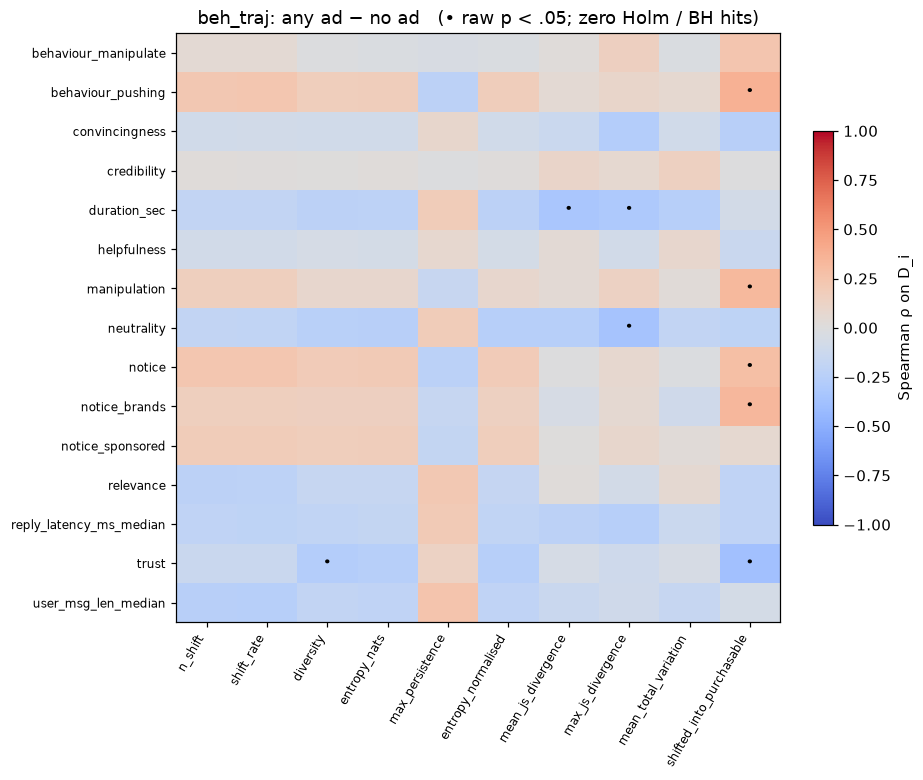

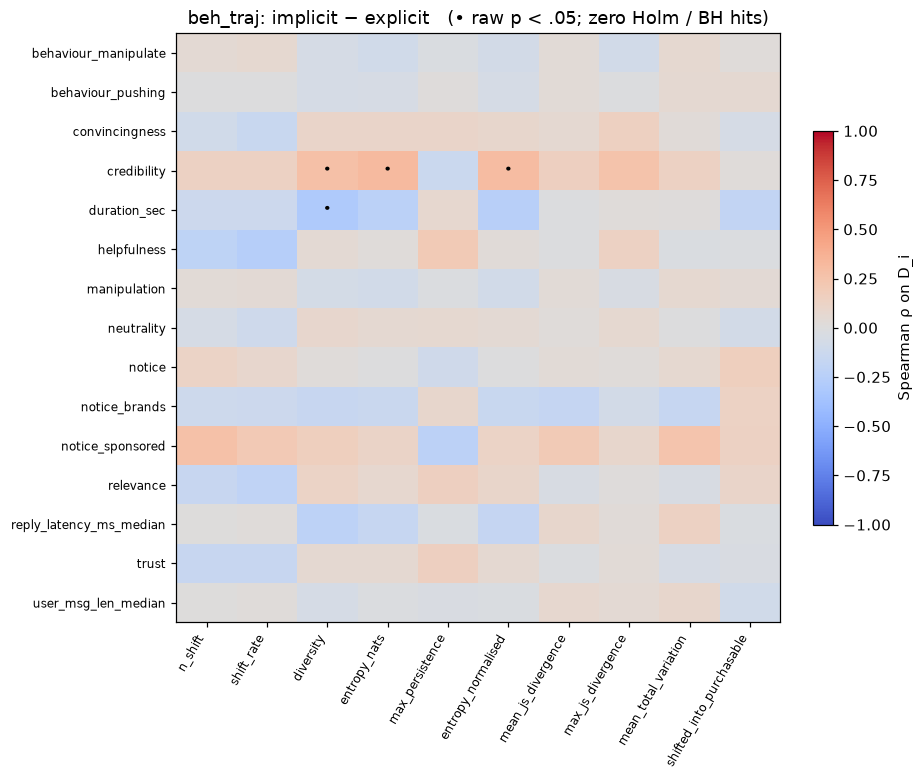

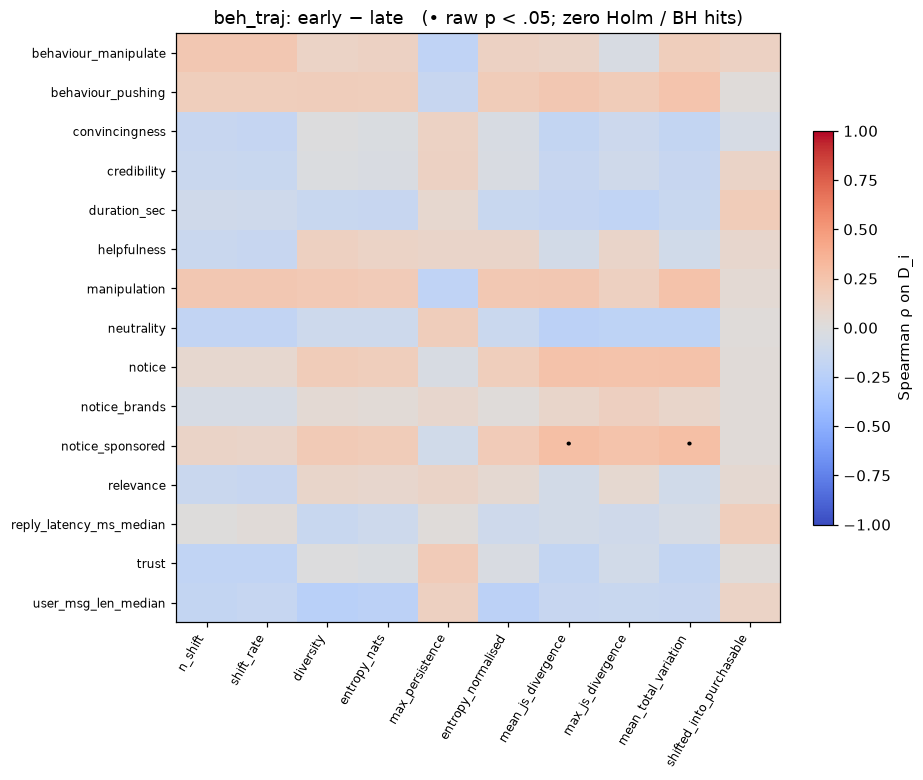

In [2]:
for cid in sk.PLANNED:
    display(viz.combo_heat(t, "beh_traj", cid, RIGHT)); plt.close()

## 2. Headline cells (primary behaviour / trajectory × headline partner)

In [3]:
h = pd.read_csv(OUT / "tests_headline.csv")
cols = [x for x in ["grain", "contrast_label", "left", "right", "n", "n_persons", "effect", "effect_name", "p_raw", "p_holm_family", "p_bh_global"] if x in h.columns]
display(h.sort_values("p_raw")[cols].head(15).round(4))

,grain,contrast_label,left,right,n,n_persons,effect,effect_name,p_raw,p_holm_family,p_bh_global
0,D,implicit − explicit,credibility,traj_entropy_nats,54.0,NaN,0.3177,Spearman rho,0.0192,1.0,0.8962
1,D,implicit − explicit,credibility,traj_diversity,54.0,NaN,0.2795,Spearman rho,0.0407,1.0,0.9958
2,D,any ad − no ad,trust,traj_diversity,54.0,NaN,-0.2694,Spearman rho,0.0488,1.0,0.9958
3,D,any ad − no ad,trust,traj_entropy_nats,54.0,NaN,-0.2555,Spearman rho,0.0622,1.0,0.9958
4,D,any ad − no ad,notice,traj_n_shift,54.0,NaN,0.2327,Spearman rho,0.0904,1.0,0.9958
5,D,any ad − no ad,notice,traj_shift_rate,54.0,NaN,0.2297,Spearman rho,0.0948,1.0,0.9958
6,D,any ad − no ad,notice,traj_max_persistence,54.0,NaN,-0.2282,Spearman rho,0.0970,1.0,0.9958
7,D,early − late,manipulation,traj_shift_rate,54.0,NaN,0.2226,Spearman rho,0.1056,1.0,0.9958
8,D,early − late,manipulation,traj_n_shift,54.0,NaN,0.2216,Spearman rho,0.1073,1.0,0.9958
60,RM,"person x condition rows, person centred",notice,traj_diversity,NaN,54.0,0.1095,r_rm,0.1078,1.0,0.9958


## 3. The three lowest raw cells, drawn (so the eye can judge what a raw p ≈ .002 looks like at this n)

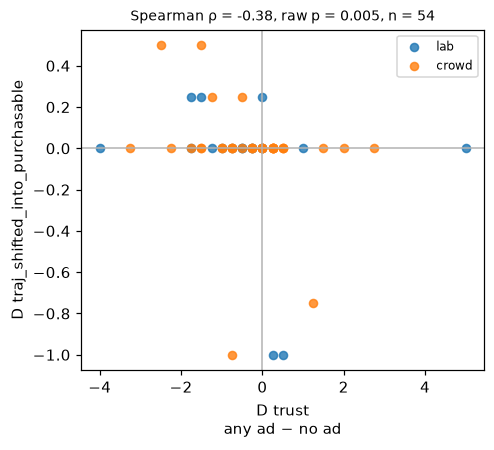

D  trust × traj_shifted_into_purchasable  any ad − no ad: effect -0.38, raw p 0.0046, Holm 0.70, BH 0.90, family size 150


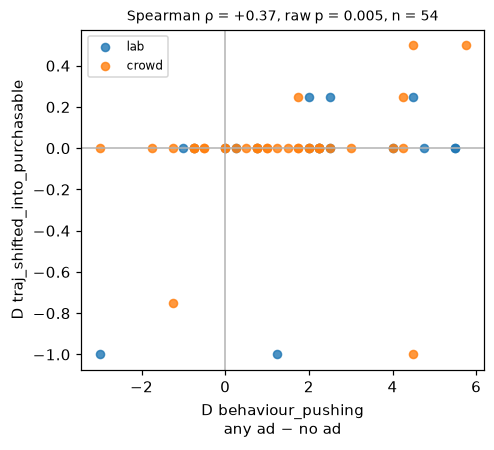

D  behaviour_pushing × traj_shifted_into_purchasable  any ad − no ad: effect +0.37, raw p 0.0055, Holm 0.82, BH 0.90, family size 150


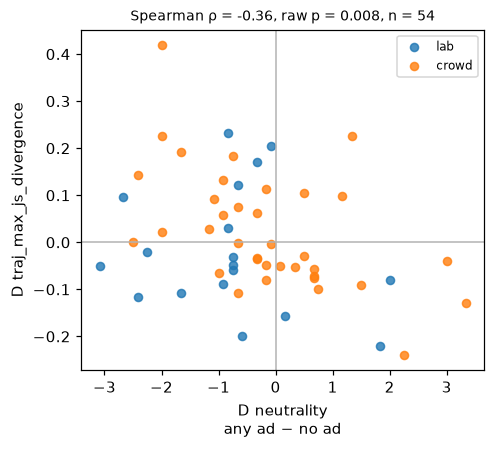

D  neutrality × traj_max_js_divergence  any ad − no ad: effect -0.36, raw p 0.0083, Holm 1.00, BH 0.90, family size 150


In [4]:
top = t.sort_values("p_raw").head(3)
for _, r in top.iterrows():
    if r.grain == "D":
        display(viz.scatter_D(dtab, r.left, r.right, r.contrast)); plt.close()
    else:
        display(viz.rm_plot(state, r.left, r.right)); plt.close()
    print(f"{r.grain}  {r.left} × {r.right}  {r.contrast_label}: effect {r.effect:+.2f}, raw p {r.p_raw:.4f}, Holm {r.p_holm_family:.2f}, BH {r.p_bh_global:.2f}, family size {int(r.n_tests_in_family)}")

## 4. RM grain: the strongest within-person association

In [5]:
rm = t[t.grain == "RM"].sort_values("p_raw").head(8)
display(rm[[x for x in ["left", "right", "n_obs", "n_persons", "dof", "effect", "p_raw", "p_holm_family", "p_bh_global"] if x in rm.columns]].round(4))

,left,right,n_obs,n_persons,dof,effect,p_raw,p_holm_family,p_bh_global
450,duration_sec,traj_diversity,270.0,54.0,215.0,-0.1752,0.0097,1.0,0.8962
451,user_msg_len_median,traj_diversity,270.0,54.0,215.0,-0.1707,0.0118,1.0,0.8962
452,reply_latency_ms_median,traj_diversity,270.0,54.0,215.0,-0.1703,0.0120,1.0,0.8962
453,duration_sec,traj_entropy_normalised,270.0,54.0,215.0,-0.1673,0.0136,1.0,0.8962
454,duration_sec,traj_entropy_nats,270.0,54.0,215.0,-0.1673,0.0136,1.0,0.8962
455,notice_sponsored,traj_max_js_divergence,270.0,54.0,215.0,0.1593,0.0189,1.0,0.8962
456,reply_latency_ms_median,traj_entropy_normalised,270.0,54.0,215.0,-0.1588,0.0193,1.0,0.8962
457,reply_latency_ms_median,traj_entropy_nats,270.0,54.0,215.0,-0.1588,0.0193,1.0,0.8962


## 5. Raw hits vs chance

raw hits 30 of 600 tests; chance expectation 30; Holm-family 0; BH-global 0


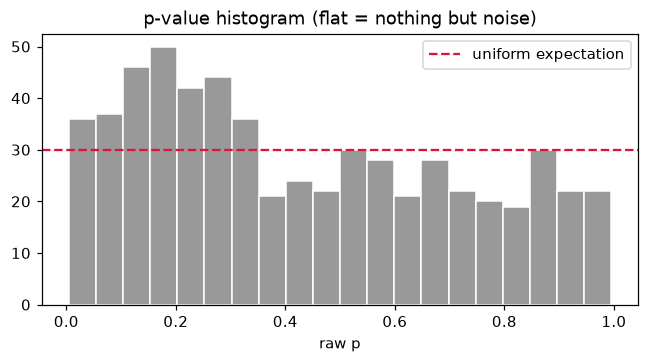

In [6]:
raw = int(t.sig_raw.sum()); print(f"raw hits {raw} of {len(t)} tests; chance expectation {0.05*len(t):.0f}; Holm-family {int(t.sig_holm_family.sum())}; BH-global {int(t.sig_bh_global.sum())}")
fig, ax = plt.subplots(figsize=(7, 3.2)); ax.hist(t.p_raw, bins=20, color="0.6", edgecolor="white"); ax.axhline(len(t)/20, color="crimson", ls="--", label="uniform expectation"); ax.set_xlabel("raw p"); ax.set_title("p-value histogram (flat = nothing but noise)"); ax.legend(); display(fig); plt.close()